# **Asignatura**: Aprendizaje Automático

**Práctica 2**: Aprendizaje No Supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 25 de Abril de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: <mark>ANDRÉS BORJA DURO</mark>



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Agrupamiento / Clustering (5 puntos)**

## 1.1 Contexto: Segmentación de Clientes en un Centro Comercial

El equipo de marketing de un gran centro comercial quiere entender mejor a sus clientes para diseñar estrategias personalizadas. Tienen datos históricos de clientes que incluyen edad, género, ingresos anuales y una "Puntuación de Gasto" (Spending Score) asignada por el centro basada en el comportamiento del cliente y la lealtad.

**Objetivo:** Utilizar técnicas de agrupamiento (Clustering) para identificar segmentos de clientes (perfiles) que compartan comportamientos similares.

**Variables:**
- `CustomerID`: ID único del cliente.
- `Gender`: Género.
- `Age`: Edad.
- `Annual Income (k$)`: Ingresos anuales en miles de dólares.
- `Spending Score (1-100)`: Puntuación de gasto (mayor puntuación = gasta más).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# Carga de datos Clustering (Mall Customers)
url='https://drive.google.com/file/d/1MrDJ-ZCgaTqxc34nAcCt0RBqOncAFTc6/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clustering = pd.read_csv(url)

print("Datos de Clientes cargados:")
display(df_clustering.head())

Datos de Clientes cargados:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1.2 Tareas de Análisis y Modelado

El alumno debe realizar las siguientes tareas documentadas:

1.  **EDA y Preprocesado:**
    * Analice la distribución de las variables (histogramas/boxplots).
    * ¿Es necesario escalar los datos? Justifique su respuesta y aplique `StandardScaler` si procede.
    * **Nota:** Para visualizar los clusters en 2D fácilmente, se recomienda utilizar principalmente las variables `Annual Income` y `Spending Score` para el entrenamiento, aunque puede probar con más.

2.  **Algoritmo K-Means:**
    * Utilice el **Método del Codo (Elbow Method)** para determinar el número óptimo de clusters ($k$). Muestre la gráfica de la inercia.
    * Entrene el modelo con el $k$ elegido.
    * Visualice los clusters resultantes y sus centroides.

3.  **Algoritmo Jerárquico (Aglomerativo) o DBSCAN:**
    * Seleccione un segundo algoritmo (DBSCAN o Clustering Jerárquico).
    * Ajuste sus hiperparámetros (ej: `eps` y `min_samples` para DBSCAN).
    * Compare visualmente los resultados con K-Means.

4.  **Interpretación (Crucial):**
    * Describa los grupos encontrados. Ejemplo: "Grupo 1: Clientes con altos ingresos pero bajo gasto (Ahorradores)".

1.  **EDA y Preprocesado:**
    * Analice la distribución de las variables (histogramas/boxplots).
    * ¿Es necesario escalar los datos? Justifique su respuesta y aplique `StandardScaler` si procede.
    * **Nota:** Para visualizar los clusters en 2D fácilmente, se recomienda utilizar principalmente las variables `Annual Income` y `Spending Score` para el entrenamiento, aunque puede probar con más.

Antes de ver todas las distribuciones primero debemos de pasar los datos de genero a 0 y 1, para poder escalarlo ya que ahora tiene valores "Male" y "Female"

In [2]:
# Convertimos 'Male' en 0 y 'Female' en 1 (o viceversa)
df_clustering['Gender'] = df_clustering['Gender'].map({'Male': 0, 'Female': 1})
print(df_clustering.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       0   19                  15                      39
1           2       0   21                  15                      81
2           3       1   20                  16                       6
3           4       1   23                  16                      77
4           5       1   31                  17                      40


Mostramos ahora los histogramas

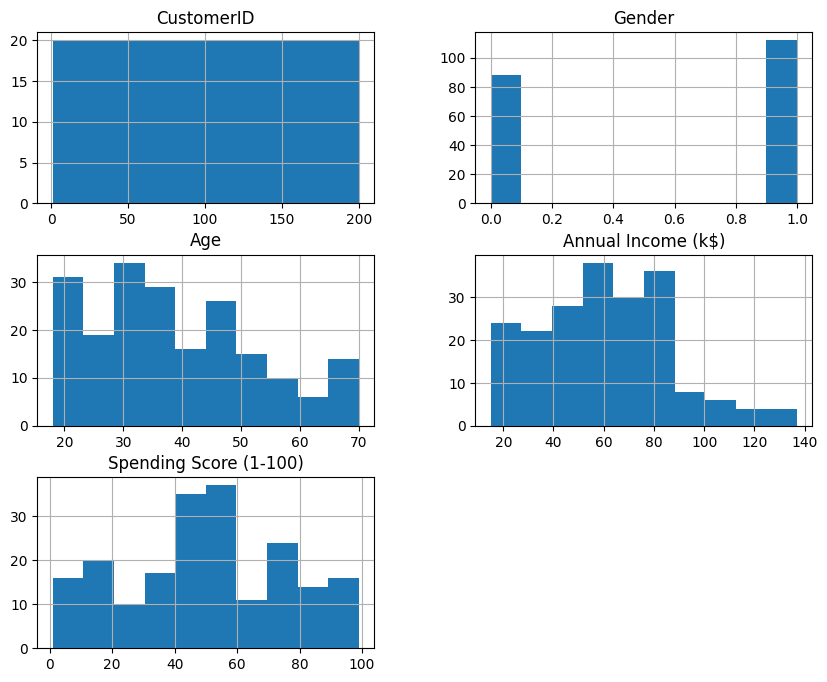

In [3]:
df_clustering.hist(figsize=(10,8))
plt.show()

El ID no tiene ningún valor analítico ni de comportamiento, no nos muestra nada porque es simplemente un identificador para cada cliente, sale a 20 porque se ha dividido en grupos de 20 entonces hay 20 ID en ese intervalo.

En cuanto a los otros:

Género: hay más mujeres que hombres, concretamente alrededor de 85 y 115 respectivamente.

Para la edad es interesante ver como la que más se repite es alrededor de los 30 años, algo que sucede también en la sociedad. Nos puede servir para descubrir un cluster de gente joven y otro de jubilados.

Ingresos: se concentran en los valores del medio, pero sin embargo a partir de 80k baja el número drasticamente, lo que nos puede mostrar que puede existir algun cluster de ingresos elevados y otro de ingresos bajos.

En cuanto al gasto, la mayoria de compradores tienen un gasto promedio, y también nos puede decir que existen grupos la gran diferencia entre el número de datos en los extremos.

Eleminamos el ID ya que no tiene ningún sentido tenerlo:

In [4]:
df_clustering = df_clustering[["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]

Mostramos los boxplots

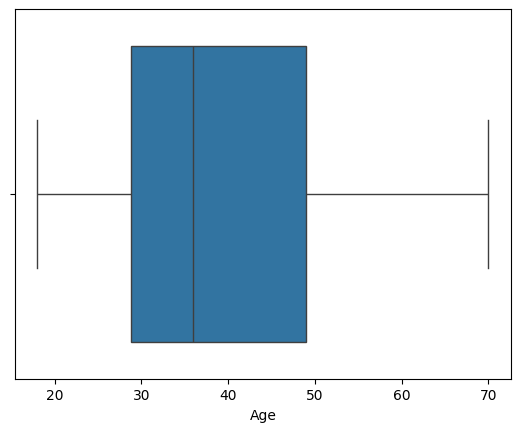

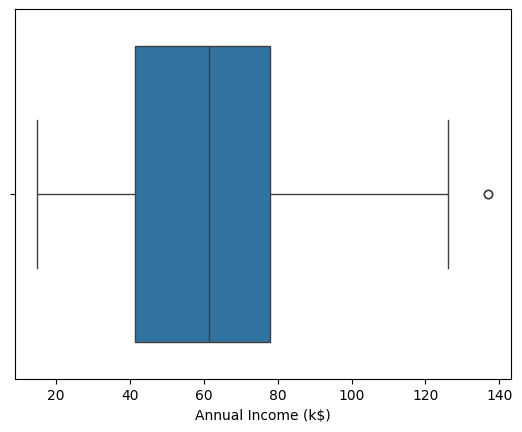

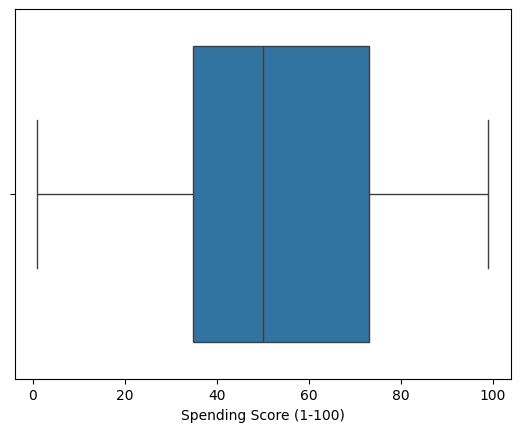

In [5]:
import seaborn as sns

for col in ["Age", "Annual Income (k$)", "Spending Score (1-100)"]:
    sns.boxplot(x=df_clustering[col])
    plt.show()

La de género no se muestra porque no tiene sentido, al tomar valores que son 0 o 1 no vamos a sacar nada interesante aquí.

Se puede ver que la distribuciones como hemos visto en los histogramas la mayor parte se encuentra entre los valores que hemos comentado anteriormente.
En los ingresos anuales, hay un punto por alrededor de 130k, esto es un outlier, que es bueno tenerlo identificado porque K-Means es sensible a estos puntos que estan muy lejos de los demás.

**¿Es necesario escalar los datos?**

La respuesta es sí, ya que el algoritmo K-Means usa la distancia euclídea para agrupar los datos, entonces si las variables que tenemos estan en diferentes escalas, lo que va a suceder es que la variable con el rango más amplio va a hacer que las otras sean practicamente insignificantes. En este caso el sueldo aplastaría a las otras dos, no es lo mismo una diferencia de 10 años que de 10k en salario, podrá darse el caso de que para el algoritmo fueran lo mismo, pero no son comparables.

Por eso esto lo solucionamos escalando los datos.

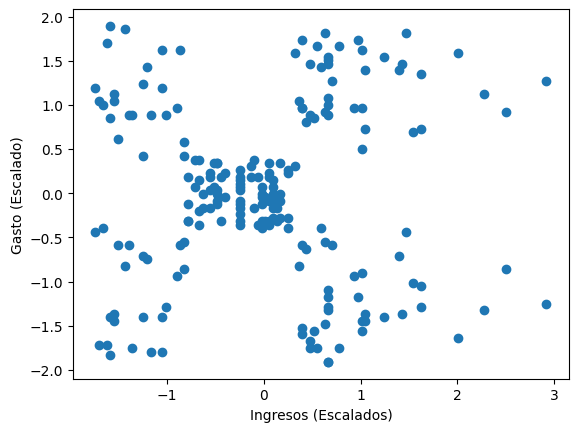

In [6]:
# Inicializamos el escalador
scaler = StandardScaler()
# Escalamos
X_scaled = scaler.fit_transform(df_clustering)

# Lo pasamos a un dataframe de pd para mantener el nombre de las columanas
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clustering.columns)

# Mostramos el grafico en 2D para los Ingresos y el Gasto
plt.scatter(X_scaled_df['Annual Income (k$)'], X_scaled_df['Spending Score (1-100)'])
plt.xlabel('Ingresos (Escalados)')
plt.ylabel('Gasto (Escalado)')
plt.show()

Mostrando los datos en 2D con su Gasto e Ingresos se pueden ver como unos 5 clusters, uno en el centro y otros cuatro con los puntos de cada esquina. De todas formas ahora veremos que esto es cierto con el Método del Codo.

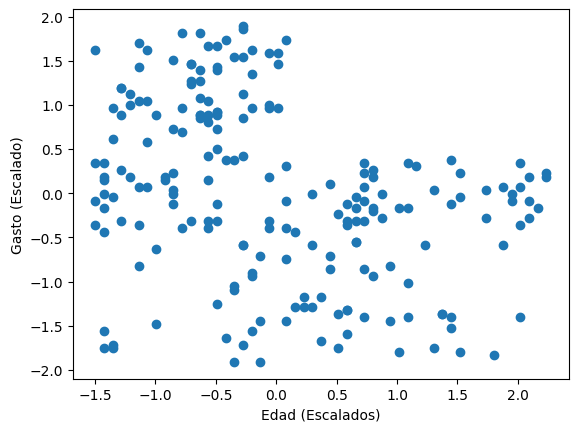

In [7]:
# Mostramos el grafico en 2D para la Edad y el Gasto
plt.scatter(X_scaled_df['Age'], X_scaled_df['Spending Score (1-100)'])
plt.xlabel('Edad (Escalados)')
plt.ylabel('Gasto (Escalado)')
plt.show()

De este gráfico no podemos sacar una conclusion tan clara como en el anterior, ya que los puntos están muchos más distribuidos, sin embargo si que se puede ver que con menor edad hay un gasto mayor, se puede deber a gente joven con hijos pequeños lo que supone un gasto mayor en las compras. Por el otro lado, los de más edad, que ya no tienen que comprar cosas para sus hijos tienen un gasto menor probablemente por esto.

2.  **Algoritmo K-Means:**
    * Utilice el **Método del Codo (Elbow Method)** para determinar el número óptimo de clusters ($k$). Muestre la gráfica de la inercia.
    * Entrene el modelo con el $k$ elegido.
    * Visualice los clusters resultantes y sus centroides.

Primero definimos la función euclidean(), para la distancia euclídea, la función predict(), para la predicción del cluster de un conjunto de patrones, la función WCSS(), para la Medida Within-Cluster Sum of Squares (WCSS) y KMeans

In [8]:
# Distancia a usar como métrica de similitud entre patrones
def euclidean(x, y):
  return np.sqrt( np.sum( (x-y)**2, axis=-1) )

In [9]:
# Cálculo del centroide más próximo a los patrones X
def predict(X, centroides):

  # Expandimos X para poder hacer cálculos de forma matricial
  # más eficientemente con la característica de NumPy para broadcasting
  X= np.repeat(X, centroides.shape[0], axis=0).reshape(-1, centroides.shape[0], centroides.shape[1])

  # Calculamos las distancias de cada elemento de X a los centroides
  distancias= euclidean(X, centroides)

  # Calculamos el cluster más próximo a cada elemento de X
  clusters= np.argmin(distancias, axis= -1)
  return clusters.reshape(-1)

In [10]:
# Cálculo de la métrica Within-Cluster Sum of Squares (WCSS).
def WCSS(X, clusters, centroides):

  wcss= 0
  for i in range(len(centroides)):
    centroid_i= centroides[i, :].squeeze()
    elementos_cluster= X[clusters==i, :].squeeze()

    distancias_sqr= euclidean(elementos_cluster, centroid_i)**2
    wcss+= np.sum(distancias_sqr)
  return wcss

In [11]:
# Algoritmo KMeans
#   X: tabla de X.shape[0] patrones de dimensión X.shape[1] a agrupar
#   n_clusters: Número de clusters a generar
#   max_iter: Máximo de iteraciones permitidas
def KMeans(X, n_clusters, max_iter, debug=False):

  # Selección de centroides aleatorios
  seleccion= np.random.choice(len(X), size=n_clusters, replace= False)
  centroides= X[seleccion].copy()

  converged= False # Parada temprana si se converge

  # Algoritmo
  for it in range(max_iter):

    # Buscamos clusters para cada elemento de X
    clusters= predict(X, centroides)

    # Recalculamos centroides
    centroides_old= centroides.copy()
    for i in range(len(centroides)):
      elementos_cluster= X[clusters==i, :].reshape(-1, X.shape[1])
      centroides[i, :]= np.mean(elementos_cluster, axis=0)

    # Comprobamos convergencia
    converged= np.all(centroides == centroides_old)
    if converged:
      if debug:
        print('CONVERGE')
      return centroides

    # Mostramos resultados
    if debug:
      wcss= WCSS(X, clusters, centroides)
      print('It. {}. WCSS: {}'.format(it+1, wcss))

  # Fin
  print('NO CONVERGE. FIN ITERACIONES.')
  return centroides



Lo que vamos a hacer ahora es aplicar el Método del Codo, lo haremos tanto a los datos solo con sus elementos en 2D de Ingresos y Gastos, que hemos visto que parecía buena opción anteriormente y también para todos los datos, simplemente para comparar ambos resultados

**MÉTODO DEL CODO SOLO PARA INGRESOS Y GASTOS**

In [12]:
# Primero nos quedamos con los datos en 2D con el ingreso y los gastos, ya que hemos visto que parecia buena opción
X_2D = X_scaled_df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_values = X_2D.values

# Diccionario para guardar los centroides de todas las pruebas
centroides_totales1= {}

wcss1= [] # Listado de WCSS para cada solución
Sscore1= [] # Listado de Silhouette Scores para cada solución



# Generamos soluciones desde 2 a max_clusters1 clusters
max_clusters1= 10
for num_clusters1 in range(2, max_clusters1+1):

  # Calculamos solución para num_clusters1 clusters
  centroides= KMeans(X_values, n_clusters=num_clusters1, max_iter= 25, debug= False)

  # Calculamos el WCSS de la solución
  clusters= predict(X_values, centroides)
  wcss1.append( WCSS(X_values, clusters, centroides) )

  # Cálculo de la S-Score
  Sscore1.append( silhouette_score(X_values, clusters) )

  # Guardamos solución
  centroides_totales1[num_clusters1]= centroides

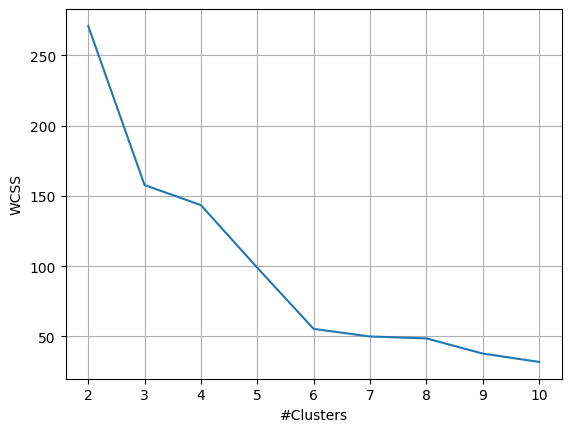

In [13]:
plt.plot(np.arange(2, max_clusters1+1), wcss1)
plt.xlabel('#Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

De aquí tras varias ejecuciones de la celda, se puede deducir que el mejor k parece ser k=5, ya que antes del mismo cae en picado y después es más plana. Este valor se corresponde al que pensabamos que podía ser en el apartado anterior. Por lo tanto es el que usaremos de aquí en adelante

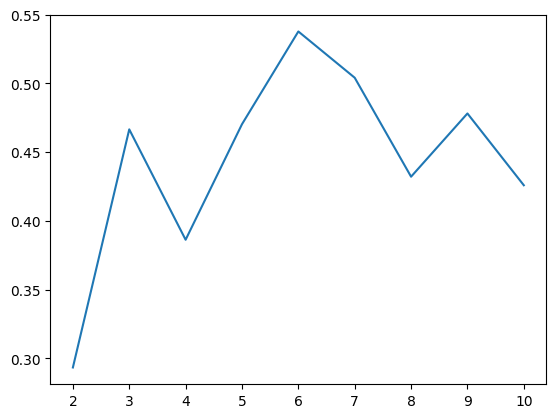

In [14]:
plt.plot( np.arange(2, max_clusters1+1), Sscore1 )

Con el Silhouette Score confirmamos nuestro resultado de k=5 al ser el que mayor valor tiene aquí.

In [15]:
k_2D = 5

**MÉTODO DEL CODO PARA TODOS LOS DATOS**

In [16]:
# Diccionario para guardar los centroides de todas las pruebas
centroides_totales= {}

wcss= [] # Listado de WCSS para cada solución
Sscore= [] # Listado de Silhouette Scores para cada solución

X_values = X_scaled_df.values

# Generamos soluciones desde 2 a max_clusters clusters
max_clusters= 10
for num_clusters in range(2, max_clusters+1):

  # Calculamos solución para num_clusters clusters
  centroides= KMeans(X_values, n_clusters=num_clusters, max_iter= 25, debug= False)

  # Calculamos el WCSS de la solución
  clusters= predict(X_values, centroides)
  wcss.append( WCSS(X_values, clusters, centroides) )

  # Cálculo de la S-Score
  Sscore.append( silhouette_score(X_values, clusters) )

  # Guardamos solución
  centroides_totales[num_clusters]= centroides

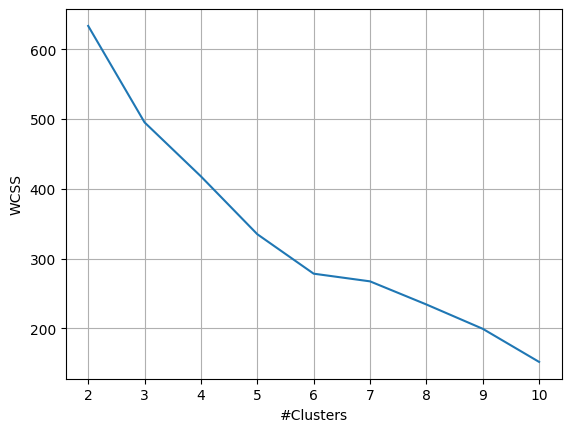

In [17]:
plt.plot(np.arange(2, max_clusters+1), wcss)
plt.xlabel('#Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

Parece ser K=8 aunque no está claro, depende de la ejecución. Tiene sentido que los valores de WCSS sean mayores cuando solo hemos usado 2 datos ya que las distancias entre puntos son mayores.

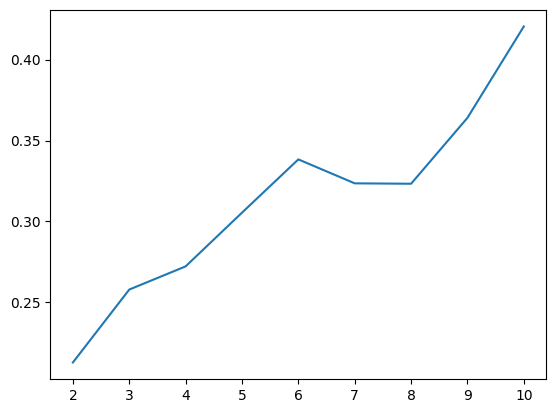

In [18]:
plt.plot( np.arange(2, max_clusters+1), Sscore )

El problema que se muestra aqui es que cuantos más clusters hay parece que el Silhouette Score es mejor, pero claro, no tendría sentido tener 200 datos y poner 200 clusters. Esto confirma que al meter Edad y Género, los datos están mucho más dispersos lo que provoca que le cueste encontrar "fronteras" claras. También es interesante ver que aquí los valores de Silhouette Score son menores que solo con los dos datos

In [19]:
k_4D = 8

**ENTRENAMIENTO DEL MODELO**

**ENTRENAMIENTO SOLO USANDO GASTOS E INGRESOS**

Primero veamos que sucede con el de Gastos e Ingresos.

Silhouette Score --->  0.5539423799434205


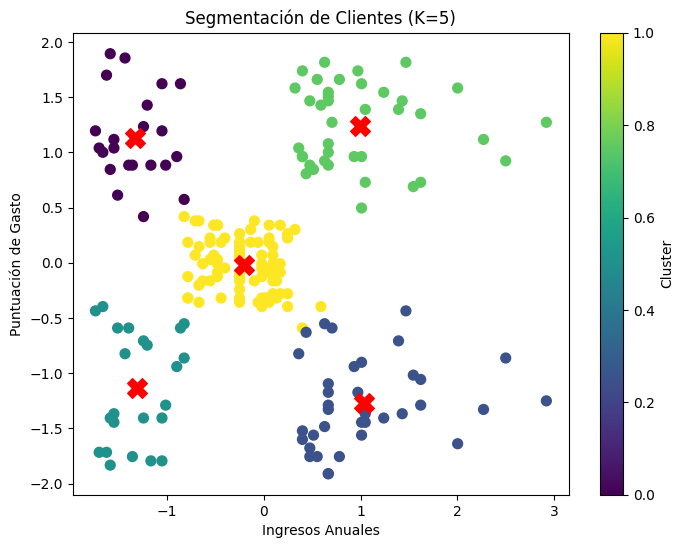

In [20]:
# Calcula los mejores centroides finales
X_2D_Values = X_2D.values
centroides_finales_2D = KMeans(X_2D_Values, n_clusters=k_2D, max_iter=1000)

# Usamos los centroides para etiquetar a los clientes
etiquetas = predict(X_2D_Values, centroides_finales_2D)

print("Silhouette Score ---> " , silhouette_score(X_2D_Values, etiquetas))

# Figura
plt.figure(figsize=(8, 6))

# Graficamos los puntos coloreados por su cluster
plt.scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
            c=etiquetas, cmap='viridis', s=50)                # viridis es para los colores, s=50 para el tamaño de los puntos
plt.scatter(centroides_finales_2D[:, 0], centroides_finales_2D[:, 1],
            s=200, c='red', marker='X', label='Centroides')
plt.title('Segmentación de Clientes (K=5)')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.colorbar(label='Cluster')
plt.show()

**ENTRENAMIENTO USANDO TODAS LAS COLUMNAS**

Ahora para las 4 columnas:

In [21]:
# Calcula los mejores centroides finales
X_4D_Values = X_scaled_df.values
centroides_finales = KMeans(X_4D_Values, n_clusters=k_4D, max_iter=1000)

# Usamos los centroides para etiquetar a los clientes
etiquetas_4d = predict(X_4D_Values, centroides_finales)

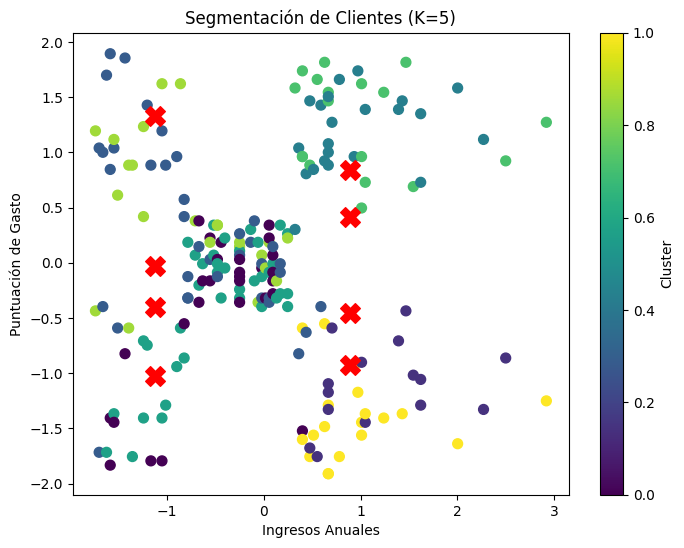

In [22]:
# Grafica
plt.figure(figsize=(8, 6))

# Graficamos los puntos coloreados por su cluster
plt.scatter(X_scaled_df['Annual Income (k$)'], X_scaled_df['Spending Score (1-100)'],
            c=etiquetas_4d, cmap='viridis', s=50)
plt.scatter(centroides_finales[:, 0], centroides_finales[:, 1],
            s=200, c='red', marker='X', label='Centroides')
plt.title('Segmentación de Clientes (K=5)')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.colorbar(label='Cluster')
plt.show()

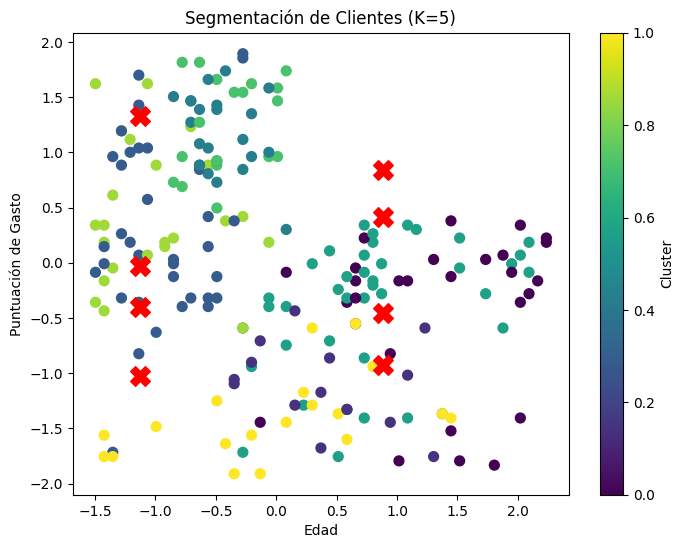

In [23]:
# Grafica
plt.figure(figsize=(8, 6))

# Graficamos los puntos coloreados por su cluster
plt.scatter(X_scaled_df['Age'], X_scaled_df['Spending Score (1-100)'],
            c=etiquetas_4d, cmap='viridis', s=50)
plt.scatter(centroides_finales[:, 0], centroides_finales[:, 1],
            s=200, c='red', marker='X', label='Centroides')
plt.title('Segmentación de Clientes (K=5)')
plt.xlabel('Edad')
plt.ylabel('Puntuación de Gasto')
plt.colorbar(label='Cluster')
plt.show()

Aunque al solo verlo graficamente en 2D para cada dos parametros de los cuatro no indica que los grupos no sean realmente buenos ya que son solo proyecciones por tanto puede que sí esten bien realmente, esto lo solucionamos viendo el Silhoutte Score, que nos da informacion que con el ojo no podemos ver (cuando hay mas de 2 elementos).

In [24]:
print("Silhouette Score ---> " , silhouette_score(X_4D_Values, etiquetas_4d))

Silhouette Score --->  0.39008810865377974


Mirando los Silhouette Score de ambos el primero esta un poco por encima de 0.5 lo que es un valor aceptable, pero este tiene un valor cerca de 0.3 que es malo. Lo que puede significar que añadir variables como Género o Edad introduce 'ruido' o complejidad que dificulta la separación clara de los grupos. Además en la gráfica del primero se ven claramente los 5 grupos y como tiene sentido.

Por lo tanto es mejor que descartemos usar el modelo con todos los elementos, sale mucho más claro con el de 2 elementos.

3.  **Algoritmo Jerárquico (Aglomerativo) o DBSCAN:**
    * Seleccione un segundo algoritmo (DBSCAN o Clustering Jerárquico).
    * Ajuste sus hiperparámetros (ej: `eps` y `min_samples` para DBSCAN).
    * Compare visualmente los resultados con K-Means.


**ALGORITMO DBSCAN**

El número de cluster es -->  4


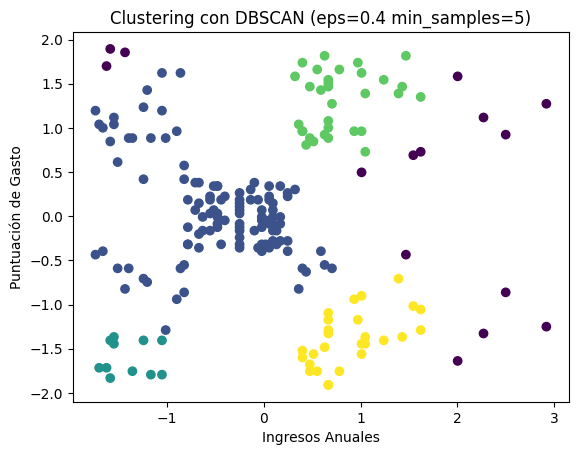

In [25]:
from sklearn.cluster import DBSCAN

X_2D_Values = X_2D.values
# Configurar DBSCAN:
# eps = radio de búsqueda.
# min_samples = número mínimo para que se considere cluster
dbscan = DBSCAN(eps=0.4, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_2D_Values)

# Le quitamos 1 si hay Outliers que los marca en el grupo -1
print("El número de cluster es --> ", len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0))

# Grafica
plt.scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
            c=labels_dbscan, cmap='viridis')
plt.title('Clustering con DBSCAN (eps=0.4 min_samples=5)')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.show()

Ahora vamos a cambiar un poco los hiperparámtros

El número de cluster es -->  6


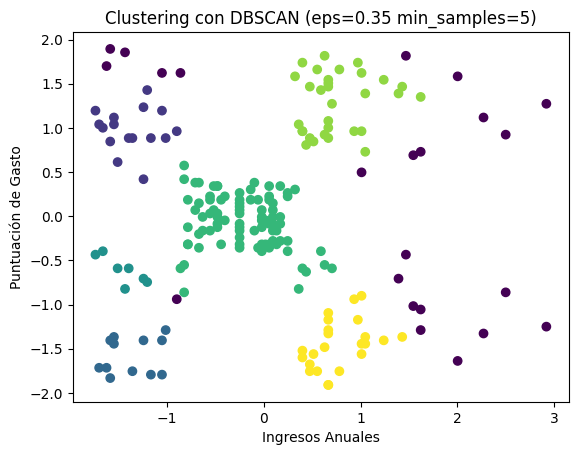

In [26]:
# Configurar DBSCAN:
# eps = radio de búsqueda.
# min_samples = número mínimo para que se considere cluster
dbscan = DBSCAN(eps=0.35, min_samples=5)
labels_dbscan_2 = dbscan.fit_predict(X_2D_Values)

# Le quitamos 1 si hay Outliers que los marca en el grupo -1
print("El número de cluster es --> ", len(set(labels_dbscan_2)) - (1 if -1 in labels_dbscan_2 else 0))

# Grafica
plt.scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
            c=labels_dbscan_2, cmap='viridis')
plt.title('Clustering con DBSCAN (eps=0.35 min_samples=5)')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Puntuación de Gasto')
plt.show()

**Comparacion DBSCAN y K-Means**

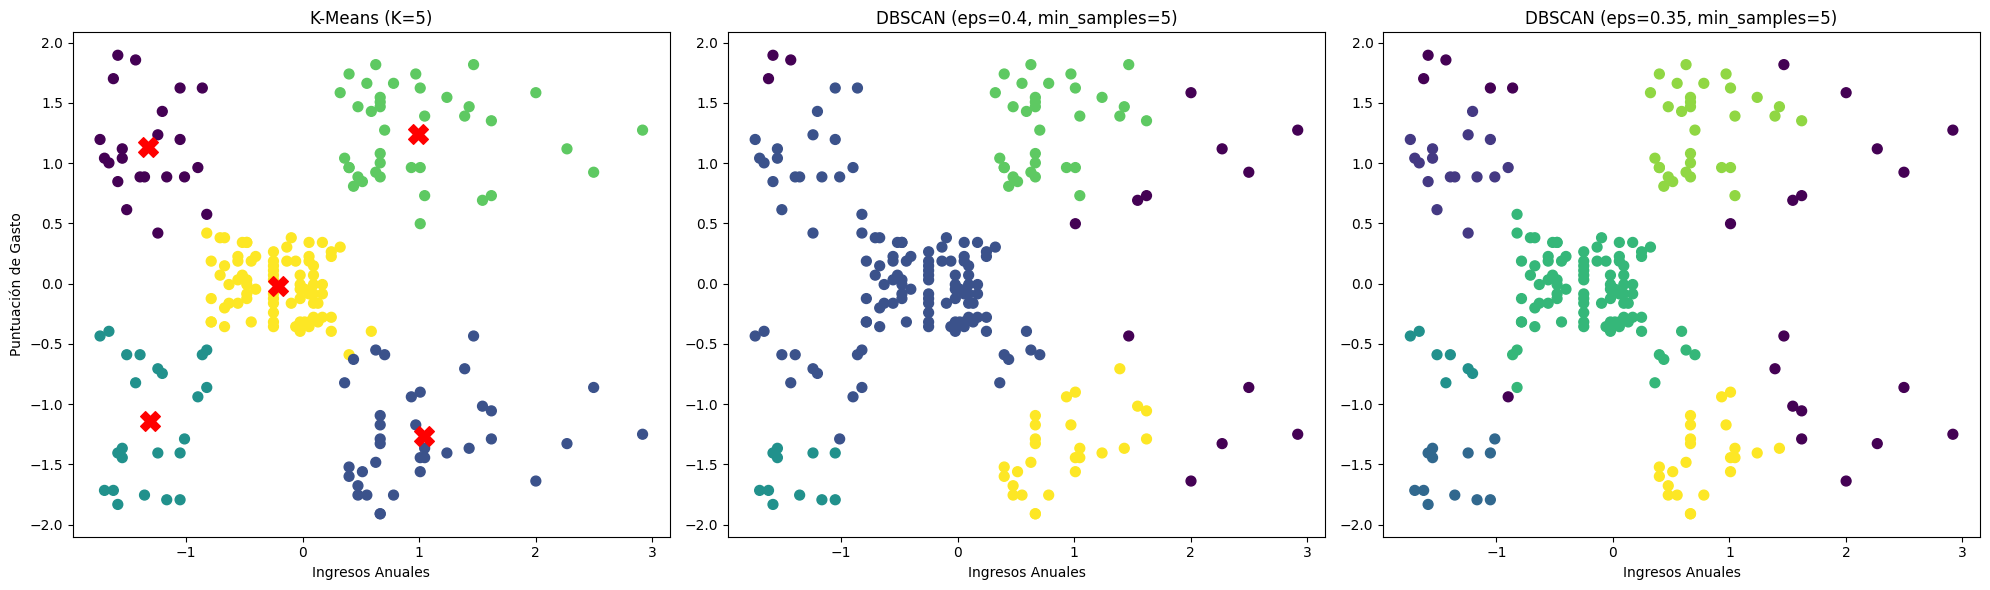

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PRIMERA GRÁFICA: K-Means ---
axes[0].scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
                c=etiquetas, cmap='viridis', s=50)
axes[0].scatter(centroides_finales_2D[:, 0], centroides_finales_2D[:, 1],
                s=200, c='red', marker='X', label='Centroides')
axes[0].set_title('K-Means (K=5)')
axes[0].set_xlabel('Ingresos Anuales')
axes[0].set_ylabel('Puntuación de Gasto')

# --- SEGUNDA GRÁFICA: DBSCAN 1 ---
axes[1].scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
                c=labels_dbscan, cmap='viridis', s=50)
axes[1].set_title('DBSCAN (eps=0.4, min_samples=5)')
axes[1].set_xlabel('Ingresos Anuales')
# No repetimos el ylabel para que quede más limpio, pero puedes ponerlo

# --- TERCERA GRÁFICA: DBSCAN 2 ---
axes[2].scatter(X_2D['Annual Income (k$)'], X_2D['Spending Score (1-100)'],
                c=labels_dbscan_2, cmap='viridis', s=50)
axes[2].set_title('DBSCAN (eps=0.35, min_samples=5)')
axes[2].set_xlabel('Ingresos Anuales')

# Ajustamos el espacio entre gráficas para que no se solapen los textos
plt.tight_layout()
plt.show()

A diferencia de K-Means este algoritmo detecta los outliers y no los pone en ningún cluster. Se muestran en color negro/morado oscuro y en este último gráfico se ven valores muy poco comunes como los que tienen un sueldo muy elevado sin importar que gasten mucho o poco (a partir del 2), y también los que tienen un salario muy bajo y tienen un gasto altísimo (arriba izquierda).
Sin embargo también es verdad que este algoritmo puede hacer que datos que no son outliers, que son clientes con un comportamiento totalmente normal, se queden sin asignar en ningun cluster, como por ejemplo un valor que hay en la tercera gráfica en (-1, -1) mas o menos, que se ha quedado sin asignar en ninguno seguramente por encontrarse un poco más alejado y no entra dentro del radio de búsqueda eps.

Sin embargo creo que para la clasificación en grupos me quedaré con el K-Means ya que en este caso no hay formas raras en la distribución de los puntos, es una distribución completamente normal y también porque los otros creo que dejan demasiados datos sin clasificar (alrededor del 10%).

4.  **Interpretación (Crucial):**

Mirando la gráfica de K-Means (k=5) tenemos claramente 5 clusters que son los siguientes:


1.   Centroide Arriba-Izquierda: Bajos ingresos pero alto gasto (Clientes que priorizan marca/calidad ante todo).
2.   Centroide Abajo-Izquierda: Bajos ingresos y bajo gasto (Clientes prudentes).
3. Centroide Centro: Ingresos y gastos medios (Cliente promedio).
4. Centroide Arriba-Derecha: Clientes con altos ingresos y alto gasto (Clientes premium).
5. Centroide Abajo-Derecha: Altos ingresos pero poco gasto (Clientes ahorradores cautelosos).



## **Conclusiones Generales**

Añada una celda de texto final reflexionando sobre la utilidad de los distintos parámetros, así como los resultados obtenidos.



1.   **Modelo funciona mejor con 2 datos**

El modelo funciona mejor solo usando Ingresos y Gasto que usando todos, es decir, Género, Edad, Ingresos y Gasto. Esto se debe a que cuando usamos los 4 elementos hace que sea muchos más complicado separarlos en grupos ya que mezcla demasiadas cosas y los grupos no son claros, sin embargo cuando usamos solo los 2 elementos, Ingresos y Gastos, salen los grupos muy claros, de hecho antes de hacer el Método del Codo se podía deducir el número de grupos que había. Además se puede ver también con el resultado obtenido en el Silhouette Score, que era mejor en el de 2 que en el de 4.
También esto se podía intuir cuando estabamos intentado determinar el k con el Método del Codo, cuando hemos usado los 4 elementos se ve que (como ya se ha explicado en ese apartado) a mayor k mejor era el Silhouette Score con 4 datos lo que indicaba que era dificil encontrar fronteras claras.

Esto se puede deber a que el ingreso y el gasto definen directamente el comportamiento económico, y sin embargo la edad y el género son elementos demográficos que no tienen tanta correlación con el gasto, dificultando encontrar grupos para el algoritmo.

2.   **Comparación con algoritmo DBSCAN**


El algoritmo DBSCAN funciona por densidad, y cuando hemos modificado alguno de los dos hiperparámetros como el radio de búsqueda eps o el número mínimo de datos en un cluster, nos hemos dado cuenta que en nuestros datos un cambio minúsculo que era pasar eps de 0.4 a 0.35, modifica los cluster por completo. Se debe a que la distribución que tenemos de los datos tiene mucha densidad en el centro y poca en zonas más proximas a las esquinas.


Este algoritmo lo mejor que tiene es que si los datos están distribuidos de formas más extrañas como espirales, anillos o lineas rectas es mucho mejor que el K-Means porque este pretende que cada punto esté lo más cerca posible del centro de su grupo, lo que da como resultado formas circulares o esféricas de cada grupo.


Además DBSCAN es excelente descartando outliers, en este escenario específico al no existir una densidad uniforme y usar un radio único para toda la distruibución, el algoritmo es incapaz de conectar los grupos más dispersos sin fusionar los más densos y además descarta algunos puntos que son "normales", cosa que no le sucede al K-Means.

Por tanto con estos datos K-Means se comporta de manera más estable y coherente.

3.   **Parámetros**


En K-Means, el parámetro k es clave. Elegir k=5 nos ha permitido obtener un equilibrio perfecto lo que nos ha generado muy buenos resultados.

En DBSCAN, los parámetros eps y min_samples he ido provando muchos cambios y los dos que he puesto son los que mejor resultado me han dado, por lo que hemos explicado antes de la distribucion un mínimo cambio podía hacer que todos se agruparan como outliers o que hubiera mas de 10 grupos.


---

# **Ejercicio 2: Reglas de Asociación (5 puntos)**

## 2.1 Contexto: Análisis de la Cesta de la Compra (Market Basket)

Un supermercado desea optimizar la disposición de sus productos en los estantes. Para ello, quiere descubrir patrones de compra conjunta entre sus clientes.

**Objetivo:** Extraer reglas de asociación (tipo "Si compra X, entonces compra Y") utilizando el algoritmo **Apriori**.

**Datos:** El dataset contiene transacciones de un supermercado durante 30 días. Cada fila representa los productos comprados por un cliente en una visita.

In [28]:
# Carga de datos Asociación (Groceries)
# Dataset con formato: member_id, item_date, item_description
url = 'https://drive.google.com/file/d/1_4DM5wEaGnZY07bXRPzHTwszXHCXhcaP/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_rules = pd.read_fwf(url, sep=',', header=None)

# Nota: Este dataset en particular viene en un formato donde cada fila tiene items variables.
# Para facilitar la carga inicial, mostramos las primeras filas crudas.
print("Datos de Transacciones cargados:")
display(df_rules.head())

Datos de Transacciones cargados:


,0
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."


## 2.2 Tareas de Análisis y Minería de Reglas

1.  **Preprocesado de Transacciones:**
    * Los datos deben transformarse a un formato adecuado para el algoritmo Apriori (una lista de listas de transacciones o una matriz One-Hot/Sparse).
    * Utilice `TransactionEncoder` de la librería `mlxtend` o funciones similares de manipulación de pandas.

2.  **Generación de Itemsets Frecuentes:**
    * Aplique algoritmos para encontrar conjuntos de productos frecuentes.
    * Fije un umbral de **Soporte (Support)** mínimo (empiece con un valor bajo, ej: 0.01 o 0.02) y justifique su elección.

3.  **Extracción de Reglas:**
    * Genere las reglas de asociación a partir de los itemsets.
    * Filtre las reglas por una métrica de calidad, preferiblemente **Lift** (Elevación) o **Confianza (Confidence)**.

4. **Comparación entre algoritmos:**
    * La solución debe utilizar al menos dos algoritmos entre los existentes en la biblioteca `mlxtend`.

4.  **Análisis de Resultados:**
    * Muestre las 5 reglas con mayor *Lift*.
    * Interprete una de las reglas obtenidas en lenguaje natural. ¿Tiene sentido comercial?

1.  **Preprocesado de Transacciones:**
    * Los datos deben transformarse a un formato adecuado para el algoritmo Apriori (una lista de listas de transacciones o una matriz One-Hot/Sparse).
    * Utilice `TransactionEncoder` de la librería `mlxtend` o funciones similares de manipulación de pandas.

In [29]:
# TODO: Inserte su código para el Ejercicio 2 aquí
# Pista: Necesitará instalar mlxtend si no está disponible: !pip install mlxtend
# Añadido para quitar un warning que sale
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Usaremos una Matriz One-Hot

In [30]:
from mlxtend.preprocessing import TransactionEncoder

transacciones = df_rules[0].apply(lambda x: x.split(',')).tolist()

te = TransactionEncoder()
dataset = te.fit(transacciones).transform(transacciones).astype(int)

print('\nTras la transformación con TransactionEncoder:')
print(dataset)

print('Podemos pasar el dataset a un Dataframe:')
df_rules_limpio= pd.DataFrame(dataset, columns=te.columns_)
df_rules_limpio.head(2)


Tras la transformación con TransactionEncoder:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Podemos pasar el dataset a un Dataframe:


,,Instant f,Instant fo,Instant food,Instant food produ,Instant food products,UHT-milk,abrasi,abrasive cleaner,artif. sweetener,...,whipped/sour cream,whisky,whit,white,white b,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


2.  **Generación de Itemsets Frecuentes:**
    * Aplique algoritmos para encontrar conjuntos de productos frecuentes.
    * Fije un umbral de **Soporte (Support)** mínimo (empiece con un valor bajo, ej: 0.01 o 0.02) y justifique su elección.

In [31]:
from mlxtend.frequent_patterns import apriori

soporte_minimo = 0.02
itemsets= apriori(df_rules_limpio, min_support=soporte_minimo, use_colnames=True)
print("Hay un total de " , len(itemsets), " conjuntos de productos, con un soporte >= ", soporte_minimo)
# Contamos cuántos itemsets tienen una longitud mayor a 1
cantidad = itemsets['itemsets'].apply(lambda x: len(x) > 1).sum()

print(f"Hay {cantidad} conjuntos con más de un producto.")
itemsets = itemsets.sort_values(by='support', ascending=False)
print(itemsets)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Hay un total de  114  conjuntos de productos, con un soporte >=  0.02
Hay 56 conjuntos con más de un producto.
      support                      itemsets
56   0.255516                  (whole milk)
38   0.193493            (other vegetables)
42   0.182308                  (rolls/buns)
48   0.170107                        (soda)
57   0.139502                      (yogurt)
..        ...                           ...
73   0.020539     (whole milk, frankfurter)
110  0.020539  (yogurt, whipped/sour cream)
63   0.020437       (yogurt, bottled water)
90   0.020437   (pip fruit, tropical fruit)
65   0.020031    (other vegetables, butter)

[114 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Se ha seleccionado un soporte mínimo de 0.02 tras observar que permite identificar bastantes asociaciones (56 conjuntos de al menos 2 productos), y que aparecen en al menos el 2% de las transacciones

Con un soporte mínimo de 0.01 salen demasiados y con 0.03 pocos.

3.  **Extracción de Reglas:**
    * Genere las reglas de asociación a partir de los itemsets.
    * Filtre las reglas por una métrica de calidad, preferiblemente **Lift** (Elevación) o **Confianza (Confidence)**.

In [32]:
from mlxtend.frequent_patterns import association_rules

# Ponemos min_threshold=0.1 para que no nos muestre reglas inútiles
rules= association_rules(itemsets, len(itemsets), metric="confidence", min_threshold=0.1)

# Filtramos por calidad
# Queremos reglas que tengan un lift > 1 como pone en las diapositivas y una confianza aceptable > 30%
reglas_filtradas = rules[(rules['lift'] > 1) & (rules['confidence'] >= 0.3)]

# Ordenamos por lift para que salgan las mejores arriba
reglas_filtradas = reglas_filtradas.sort_values(by='lift', ascending=False)

# Mostramos las 10 mejores reglas
print(f"Se han extraído {len(reglas_filtradas)} reglas de alta calidad.")
display(reglas_filtradas.head(10))

Se han extraído 35 reglas de alta calidad.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
72,"(whole milk, other vegetables)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235
70,"(root vegetables, whole milk)",(other vegetables),0.048907,0.193493,0.023183,0.474012,2.449770,1.0,0.013719,1.533320,0.622230,0.105751,0.347821,0.296912
8,(root vegetables),(other vegetables),0.108998,0.193493,0.047382,0.434701,2.246605,1.0,0.026291,1.426693,0.622764,0.185731,0.299078,0.339789
47,(whipped/sour cream),(other vegetables),0.071479,0.193493,0.028673,0.401138,2.073143,1.0,0.014842,1.346733,0.557490,0.121343,0.257462,0.274663
78,"(whole milk, yogurt)",(other vegetables),0.056024,0.193493,0.022267,0.397459,2.054131,1.0,0.011427,1.338511,0.543633,0.097987,0.252901,0.256270
80,"(yogurt, other vegetables)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,1.0,0.011174,1.528340,0.524577,0.080485,0.345695,0.300014
51,(butter),(whole milk),0.055414,0.255516,0.027555,0.497248,1.946053,1.0,0.013395,1.480817,0.514659,0.097237,0.324697,0.302543
88,(pork),(other vegetables),0.057651,0.193493,0.021657,0.375661,1.941476,1.0,0.010502,1.291779,0.514595,0.094373,0.225874,0.243795
55,(curd),(whole milk),0.053279,0.255516,0.026131,0.490458,1.919481,1.0,0.012517,1.461085,0.505984,0.092446,0.315577,0.296363
71,"(root vegetables, other vegetables)",(whole milk),0.047382,0.255516,0.023183,0.489270,1.914833,1.0,0.011076,1.457687,0.501524,0.082879,0.313982,0.289999


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Para Lift ponemos un valor mayor a 1 para ver que productos realmente están relacionados entre sí, separando las compras casuales de los patrones reales.

Ponemos un valor en la confianza mayor o igual a 0.3. Esto hace que las reglas que mostramos sean fiables, no se pone más porque hay muchos productos y muchos clientes, un valor del 0.5 o superior dice que 5 de cada 10 tickets donde sale A también sale B y eso muy difícil que suceda. Podemos ver esto en la celda de abajo donde se hace y solo nos da una regla.

In [33]:
###  Confianza >= 0.5
reglas_filtradas_2 = rules[(rules['lift'] > 1) & (rules['confidence'] >= 0.5)]
reglas_filtradas_2 = reglas_filtradas_2.sort_values(by='lift', ascending=False)
print(f"Se han extraído {len(reglas_filtradas_2)} reglas de alta calidad.")
display(reglas_filtradas_2.head(10))

Se han extraído 1 reglas de alta calidad.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
80,"(yogurt, other vegetables)",(whole milk),0.043416,0.255516,0.022267,0.512881,2.007235,1.0,0.011174,1.52834,0.524577,0.080485,0.345695,0.300014


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

4. **Comparación entre algoritmos:**
    * La solución debe utilizar al menos dos algoritmos entre los existentes en la biblioteca `mlxtend`.

Para encontrar qué productos se suelen comprar juntos, he probado tres métodos distintos:

- Apriori: Funciona primero eliminando los productos individuales que no llegan al soporte mínimo y después va probando todas las combinaciones posibles y eliminado las que no van cumpliendo el soporte mínimo. Es el que funciona de forma más sencilla, pero cuando hay muchos datos se vuelve lento, aunque en nuestro caso como no tenemos tantos no es el más lento.

- FPGrowth: Funciona creando un arbol de frecuencias de las transacciones donde en cada dato va reutilizando las ramas que  ya hay si el producto ya estaba y si no estaba crea una rama nueva. El resultado final es el mismo que usando Apriori pero funciona de una forma mucho más eficiente que Apriori pero solo se nota esa mejoría cuando tenemos muchísimos datos, como no es el caso, es más lento, ya que en crear el arból tarda bastante y no compensa con tan pocos datos.

- FPMax: Funciona de forma similar a FPGrowh pero con conjuntos máximos. Un conjunto es máximo si es frecuente y no existe ningún otro conjunto frecuente que lo contenga. Primero organiza la información en un arbol, para encontrar las combinaciones de productos más largas. Mientras analiza los datos va guardando en una lista los grupos máximales hasta ese momento para ver si un grupo nuevo es un subconjunto de uno de la lista, en este caso lo descarta para no repetir información. Como resultado final muestra los conjuntos máximales y no los subgrupos de estos. Por ejemplo, si mucha gente compra {Pan, Leche, Huevos}, este algoritmo solo te muestra el grupo de tres y se ahorra enseñarte que también compran {Pan, Leche} por separado.

In [34]:
import time
from mlxtend.frequent_patterns import fpgrowth, fpmax

# --- TEST CON APRIORI ---
start_time = time.time()
itemsets_apriori = apriori(df_rules_limpio, min_support=0.02, use_colnames=True)
apriori_time = time.time() - start_time

# --- TEST CON FPGROWTH ---
start_time = time.time()
itemsets_fp = fpgrowth(df_rules_limpio, min_support=0.02, use_colnames=True)
fp_time = time.time() - start_time

# --- TEST CON FPMAX ---
start_time = time.time()
itemsets_max = fpmax(df_rules_limpio, min_support=0.02, use_colnames=True)
fpmax_time = time.time() - start_time

print("--------------- TIEMPOS ---------------")
print(f"Tiempo Apriori: {apriori_time:.4f} segundos")
print(f"Tiempo FPGrowth: {fp_time:.4f} segundos")
print(f"Tiempo FPMax: {fpmax_time:.4f} segundos\n")

print("--------------- TAMAÑO RESULTADOS ---------------")
print(f"Tamaño Apriori: ", len(itemsets_apriori))
print(f"Tamaño FPGrowth: ", len(itemsets_fp))
print(f"Tamaño FPMax: ", len(itemsets_max))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--------------- TIEMPOS ---------------
Tiempo Apriori: 0.5209 segundos
Tiempo FPGrowth: 3.5691 segundos
Tiempo FPMax: 2.5489 segundos

--------------- TAMAÑO RESULTADOS ---------------
Tamaño Apriori:  114
Tamaño FPGrowth:  114
Tamaño FPMax:  85


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [35]:
print("--------------- APRIORI ---------------")
print(itemsets_apriori.sort_values(by='support', ascending=False).head(), "\n")
print("--------------- FPGROWTH ---------------")
print(itemsets_fp.sort_values(by='support', ascending=False).head())
print("--------------- FPMAX ---------------")
print(itemsets_max.sort_values(by='support', ascending=False).head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--------------- APRIORI ---------------
     support            itemsets
56  0.255516        (whole milk)
38  0.193493  (other vegetables)
42  0.182308        (rolls/buns)
48  0.170107              (soda)
57  0.139502            (yogurt) 

--------------- FPGROWTH ---------------
     support            itemsets
5   0.255516        (whole milk)
8   0.193493  (other vegetables)
11  0.182308        (rolls/buns)
19  0.170107              (soda)
2   0.139502            (yogurt)
--------------- FPMAX ---------------
     support                  itemsets
52  0.077377            (bottled beer)
51  0.076360             (canned beer)
35  0.056228                  (coffee)
84  0.055211  (whole milk, rolls/buns)
30  0.047077       (frozen vegetables)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Vemos que como hemos dicho antes que efectivamente coinciden los resultados de Apriori y FPGrowth y es diferente el de FPMAX, que por ejemplo la leche no aparace sola porque ya aparece en la fila 5 en un conjunto mayor: 84  0.055211  (whole milk, rolls/buns)

4.  **Análisis de Resultados:**
    * Muestre las 5 reglas con mayor *Lift*.
    * Interprete una de las reglas obtenidas en lenguaje natural. ¿Tiene sentido comercial?

**Resultados con APRIORI**

In [36]:
display(reglas_filtradas.head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
72,"(whole milk, other vegetables)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235
70,"(root vegetables, whole milk)",(other vegetables),0.048907,0.193493,0.023183,0.474012,2.449770,1.0,0.013719,1.533320,0.622230,0.105751,0.347821,0.296912
8,(root vegetables),(other vegetables),0.108998,0.193493,0.047382,0.434701,2.246605,1.0,0.026291,1.426693,0.622764,0.185731,0.299078,0.339789
47,(whipped/sour cream),(other vegetables),0.071479,0.193493,0.028673,0.401138,2.073143,1.0,0.014842,1.346733,0.557490,0.121343,0.257462,0.274663
78,"(whole milk, yogurt)",(other vegetables),0.056024,0.193493,0.022267,0.397459,2.054131,1.0,0.011427,1.338511,0.543633,0.097987,0.252901,0.256270


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

- Analizando: {root vegetables} --> {other vegetables}

Casi cualquier receta que utilice verduras de raíz como un sofrito suele terminar necesitando otros vegetales. Es el comportamiento típico de alguien que está haciendo la compra semanal de frescos.


- Si analizamos {yogurt, whole milk} --> 	{other vegetables}

Parece de primeras que la leche y el yogurt no tienen nada que ver con los vegetales, sin embargo se puede entender como una compra semanal, donde el cliente es probable que si compra yogurt y leche, también compre verduras, para rellenar el frigorífico. Entonces podemos poner en la distribución de la tienda al principio el yogurt y la leche, y al final del recorrido los vegetales haciendo que el cliente tenga que recorrer la tienda entera y pueda "picar" en algun producto u oferta que no tenía pensado llevarse.

No es posible generar reglas de asociación utilizando los resultados de FPMax, ya que este algoritmo descarta los soportes de los ítems individuales si están contenidos en conjuntos mayores. Para el cálculo de métricas como el Lift y la Confianza, es necesario contar con el soporte de los antecedentes y consecuentes por separado, por lo que se utilizaron los resultados de Apriori solamente.

---

## **Conclusiones Generales**

Añada una celda de texto final reflexionando sobre la utilidad de los distintos parámetros, así como los resultados obtenidos.

1. **Parámetros**

La elección correcta de los parámetros ha sido esencial:
- El soporte a 0.02 permite eliminar transacciones practicamente irrelvantes que lo harían mucho más costoso.

- Confianza mayor o igual a 0.3 hace que las reglas que mostramos sean fiables, no se pone más porque hay muchos productos y muchos clientes, un valor del 0.5 o superior dice que al menos en 5 de cada 10 tickets donde sale A también sale B y eso muy difícil que suceda.

- Lift mayor a 1 para ver que productos realmente están relacionados entre sí, separando las compras casuales de los patrones reales.
<br>

2. **Uso de otros algoritmos**

Como hemos comentado arriba por el numero de datos que tenemos Apriori es más rápido que FPGrowth aunque con más datos no es así. El resultado que obtenemos es el mismo con FPGrowth y Apriori, sin embargo no con FPMax, que solo muestra los conjuntos maximales. Aunque FPMax no sirve para generar reglas de asociación al eliminar los soportes de los productos individuales, sin embargo me he informado y puede ser de utilidad en temas de ADN ya que a los científicos no les sirve saber que una letra se repite, quieren encontrar el segmento más largo posible que se repite en diferentes muestras.
<br>
<br>

3. **Resultados**

Cuando hemos mostrado los resultados todos los lift de las reglas mostradas estaban por encima de 2, lo que significa que si se da la compra de A es muy probable que implique comprar B. Hay reglas como la primera analizada entre dos tipos de verduras que era de esperar que aparecieran pero otras no tanto con leche, yogurt y verduras.

Es importante saber analizar las reglas, porque como hemos explicado antes la del yogurt, leche y verduras podemos analizarla para que en una tienda física le hagamos recorrer la tienda entera al cliente, pero con las verduras no tiene sentido hacer esto, tiene más sentido colocarlas juntas.
<br>
<br>

4. **Comentario adicional**

También podría ser interesante obtener los resultados cuando Lift < 1 para ver que productos son los que más se repelen. Estaría bien para no recomendar productos a los clientes que no vayan a comprar, por ejemplo si diferenciamos por marcas los productos podemos evitar que a un cliente que acaba de comprar un producto de una marca le recomendemos el mismo de la marca rival. Otro caso puede ser para que a un cliente que compre muchos productos veganos o vegetarianos no recomendarle comprar carne.